# Sistema Predictivo de Distemper Canino (Canine Distemper Virus - CDV)
## Evaluación Experimental, Comparación de Modelos y Soporte a la Decisión Clínica (CDSS)

**Marco de Calidad:** CRISP-ML(Q) (*Cross-Industry Standard Process for Machine Learning with Quality Assurance*)  
**Dominio Biomédico:** Medicina Veterinaria — Diagnóstico y Triaje Infeccioso Canino  
**Protocolo Metodológico:** Validación Cruzada Estratificada Anidada (5 pliegues Out-Of-Fold)  
**Dataset de Estudio:** `data/raw/dataset_moquillo_real_v5.csv` ($N=120$ registros clínicos reales)  
**Objetivo de este Cuaderno:** Presentación académica, visualización auditable y análisis reproducible de los modelos previamente entrenados y sus métricas oficiales.


---
# 1. CONTEXTO DEL PROYECTO

### Moquillo Canino (Canine Distemper Virus - CDV)
El virus del distemper canino (CDV) es un agente viral altamente contagioso, perteneciente a la familia *Paramyxoviridae* (género *Morbillivirus*). Afecta de manera multisistémica a caninos domésticos y carnívoros silvestres, comprometiendo de forma secuencial o simultánea los tractos respiratorio, gastrointestinal, epitelial y nervioso central. Su tasa de letalidad puede superar el 50% en cachorros y animales no vacunados, y en aquellos que sobreviven suele dejar secuelas neurológicas irreversibles (mioclonías, paresias, convulsiones).

### Formulación del Problema: Clasificación Binaria Supervisada
El reto clínico se modela como un problema de **clasificación binaria supervisada**:
* **Clase Positiva ($y = 1$):** Canino con diagnóstico confirmado de Moquillo Canino (CDV).
* **Clase Negativa / Control ($y = 0$):** Canino sano o con cuadro clínico compatible descartado para CDV.

### Objetivo del Sistema
Desarrollar y evaluar un sistema de soporte a la decisión clínica (CDSS) capaz de estimar la probabilidad de infección y estratificar el nivel de riesgo del paciente a partir de 11 variables clínicas no invasivas disponibles en la consulta inicial de triaje (edad, estado vacunal, señales generales y signos clínicos cardinales).

### Significado de las Predicciones Clínicas
* **Predicción Positiva ($\hat{y} = 1$):** El modelo detecta una alta concordancia patológica con CDV. Activa de inmediato protocolos de bioseguridad: **aislamiento estricto**, soporte sintomático intensivo y confirmación por pruebas moleculares (RT-PCR / antígeno rápido).
* **Predicción Negativa ($\hat{y} = 0$):** El modelo estima baja probabilidad de infección por CDV en la presentación clínica actual. Permite continuar el protocolo de medicina interna general sin saturar las áreas de aislamiento hospitalario.

> **Advertencia Bioética y Regulatoria Fundamental:**  
> Este desarrollo constituye una **herramienta tecnológica de apoyo a la decisión clínica (CDSS)** y **NO un diagnóstico veterinario autónomo**. No reemplaza la anamnesis, el examen físico detallado, el criterio profesional del médico veterinario ni las pruebas de laboratorio de referencia.


---
# 2. IMPORTACIÓN DE LIBRERÍAS Y ENTORNO

Para garantizar la **reproducibilidad académica estricta**, utilizamos librerías científicas consolidadas:
* `pandas` y `numpy` para manipulación tabular y álgebra computacional.
* `matplotlib` para generación gráfica sobria, limpia y de alta resolución.
* `scikit-learn` para inspección de métricas, curvas ROC/PR y validación cruzada.
* `joblib` para la carga segura de pipelines serializados.
* `json` para la ingesta del reporte oficial auditable.

La resolución de rutas se configura de forma dinámica y robusta utilizando `pathlib.Path`, permitiendo que el cuaderno se ejecute correctamente tanto desde la carpeta `evaluation/` como desde la raíz del repositorio.


In [1]:
import os
import sys
import json
import joblib
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
    precision_recall_curve,
    average_precision_score,
    classification_report
)
from sklearn.model_selection import StratifiedKFold
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# 1. Resolución robusta de rutas del proyecto
CURRENT_DIR = Path.cwd()
if CURRENT_DIR.name == "evaluation":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# 2. Definición de rutas canónicas de artefactos
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset_moquillo_real_v5.csv"
REPORT_JSON_PATH = PROJECT_ROOT / "demo_reports" / "reporte_metricas_cdv.json"
ARTIFACTS_DIR = PROJECT_ROOT / "src" / "data" / "artifacts"
RF_PIPELINE_PATH = ARTIFACTS_DIR / "cdv_randomforest_pipeline.pkl"
DT_PIPELINE_PATH = ARTIFACTS_DIR / "cdv_decisiontree_pipeline.pkl"
LR_PIPELINE_PATH = ARTIFACTS_DIR / "cdv_logisticregression_pipeline.pkl"

# 3. Configuración estética global de gráficos (estilo académico sobrio)
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.titlesize'] = 13
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['xtick.labelsize'] = 9
plt.rcParams['ytick.labelsize'] = 9
plt.rcParams['legend.fontsize'] = 9
plt.rcParams['figure.dpi'] = 110

# 4. Verificación de existencia de artefactos requeridos
print("=== VERIFICACIÓN DE RUTAS Y ARTEFACTOS ===")
print(f"Raíz del Proyecto: {PROJECT_ROOT}")
print(f"Dataset CSV      : {'EXISTE' if DATA_PATH.is_file() else 'NO ENCONTRADO'}")
print(f"Reporte JSON     : {'EXISTE' if REPORT_JSON_PATH.is_file() else 'NO ENCONTRADO'}")
print(f"Pipeline RF      : {'EXISTE' if RF_PIPELINE_PATH.is_file() else 'NO ENCONTRADO'}")
print(f"Pipeline DT      : {'EXISTE' if DT_PIPELINE_PATH.is_file() else 'NO ENCONTRADO'}")
print(f"Pipeline LR      : {'EXISTE' if LR_PIPELINE_PATH.is_file() else 'NO ENCONTRADO'}")


=== VERIFICACIÓN DE RUTAS Y ARTEFACTOS ===
Raíz del Proyecto: C:\Users\lssof\OneDrive\Desktop\Universidad\Investigacion2\distemper-canino-predictivo
Dataset CSV      : EXISTE
Reporte JSON     : EXISTE
Pipeline RF      : EXISTE
Pipeline DT      : EXISTE
Pipeline LR      : EXISTE


---
# 3. CARGA Y CONTRATO DE DATOS

En esta sección cargamos la cohorte clínica real de **120 caninos** y verificamos el cumplimiento estricto del contrato de datos definido en `src/data/dataValidation.py` mediante la clase `CDVDataValidator`.


In [2]:
from src.data.dataValidation import CDVDataValidator

# Cargar el dataset tabular
raw_df = pd.read_csv(DATA_PATH)

# Validar y normalizar mediante el validador contractual oficial
validator = CDVDataValidator()
df, quality_report = validator.validate_and_clean(raw_df)

print(f"Dimensiones del dataset: {df.shape[0]} filas × {df.shape[1]} columnas")
print(f"Total de valores nulos estructurales: {df.isnull().sum().sum()}")
print(f"Centros veterinarios / zonas detectadas: {quality_report.unique_locations}")
print(f"Cumplimiento contractual estricto: {quality_report.is_valid}")

# Primeras 5 observaciones clínicas
df.head(5)


,edad_meses,sexo,raza,talla,ubicacion_procedencia,estado_vacunal,fiebre_hipertermia,signos_respiratorios_oculonasales,signos_digestivos,signos_neurologicos,signos_dermatologicos,diagnostico_cdv_confirmado
0,4.0,Macho,Border Collie,Mediano,Bogota - Zona Norte,Incompleto,1,0,0,1,1,1
1,84.0,Hembra,Mestizo,Mediano,Bogota - Zona Centro,Desconocido,1,1,0,1,0,1
2,5.0,Macho,Husky Siberiano,Grande,Chia (Sabana Norte),Incompleto,1,1,0,1,0,1
3,2.5,Macho,Golden Retriever,Grande,Bogota - Zona Norte,No vacunado,0,0,0,1,0,1
4,6.0,Hembra,Mestizo,Mediano,Chia (Sabana Norte),Desconocido,1,0,0,1,0,1


Dimensiones del dataset: 120 filas × 12 columnas
Total de valores nulos estructurales: 0
Centros veterinarios / zonas detectadas: 13
Cumplimiento contractual estricto: True


### Diccionario Clínico de Variables Predictoras (11) y Variable Objetivo (1)

| Variable | Tipo | Categorías / Rango | Rol en el Modelo | Descripción Clínica |
|---|---|---|---|---|
| `edad_meses` | Numérica (float) | 1.0 – 180.0 meses | Predictora | Edad del animal; cachorros y gerontes tienen mayor vulnerabilidad inmunológica. |
| `sexo` | Categórica | Macho, Hembra | Predictora | Variable demográfica del paciente canino. |
| `raza` | Categórica | 10 razas frecuentes + Infrecuentes | Predictora | Genética y predisposición morfofisiológica. |
| `talla` | Categórica | Pequeño, Mediano, Grande | Predictora | Contextura física y conformación corporal. |
| `ubicacion_procedencia` | Categórica | 13 zonas (Bogotá y Sabana) | Predictora | Zona geográfica de consulta para correlación epidemiológica local. |
| `estado_vacunal` | Categórica | Completo, Incompleto, No vacunado, Desconocido | Predictora | Historial de inmunización previa reportado por el tutor. |
| `fiebre_hipertermia` | Binaria (0/1) | 0 = Ausente, 1 = Presente | Predictora | Signo cardinal de respuesta inflamatoria/viral aguda. |
| `signos_respiratorios_oculonasales` | Binaria (0/1) | 0 = Ausente, 1 = Presente | Predictora | Descarga oculonasal, tos, rinitis y disnea típicas de fase sistémica. |
| `signos_digestivos` | Binaria (0/1) | 0 = Ausente, 1 = Presente | Predictora | Vómito, diarrea y deshidratación temprana. |
| `signos_neurologicos` | Binaria (0/1) | 0 = Ausente, 1 = Presente | Predictora | Mioclonías, ataxia, hiperestesia y convulsiones (fase neurotrópica tardía). |
| `signos_dermatologicos` | Binaria (0/1) | 0 = Ausente, 1 = Presente | Predictora | Hiperqueratosis de almohadillas plantares y trufa o dermatitis pustular. |
| `diagnostico_cdv_confirmado` | Binaria (0/1) | 0 = Sano / Control, 1 = Positivo CDV | **Variable Objetivo (Target)** | Diagnóstico confirmatorio definitivo de la cohorte clínica. |


In [3]:
# Distribución de la variable objetivo
target_col = CDVDataValidator.TARGET_COLUMN
counts = df[target_col].value_counts().sort_index()
percentages = (counts / len(df) * 100).round(1)

target_summary = pd.DataFrame({
    'Condición Clínica': ['Sano / Control Negativo (0)', 'Positivo CDV Confirmado (1)'],
    'Número de Pacientes': counts.values,
    'Porcentaje (%)': percentages.values
})
target_summary


,Condición Clínica,Número de Pacientes,Porcentaje (%)
0,Sano / Control Negativo (0),31,25.8
1,Positivo CDV Confirmado (1),89,74.2


### Interpretación Académica de la Distribución de Clases
La cohorte clínica presenta **89 casos positivos (74.2%)** y **31 casos sanos o controles negativos (25.8%)**. Esta asimetría refleja una prevalencia típica de centros veterinarios de urgencia y referencia diagnóstica en Bogotá y la Sabana Norte, donde acuden pacientes predominantemente sintomáticos. 

> **Implicación Metodológica Crucial:**  
> Ante un desbalance de 74.2% vs 25.8%, la métrica de **Exactitud (Accuracy) es insuficiente por sí sola** (un clasificador trivial que predijera "Positivo" a todos obtendría 74.2% de accuracy sin valor clínico alguno). Se requiere priorizar **Sensibilidad / Recall**, **Especificidad**, **F1-Score** y **Balanced Accuracy**.


---
# 4. ANÁLISIS EXPLORATORIO DE DATOS (EDA)

A continuación construimos las 5 visualizaciones exploratorias cardinales directamente a partir de las 120 observaciones clínicas.


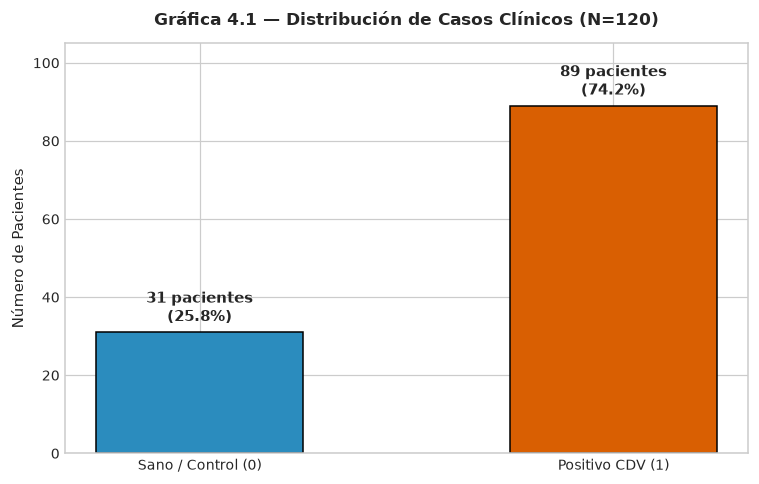

In [4]:
# Gráfica 4.1: Distribución del Diagnóstico
fig, ax = plt.subplots(figsize=(7, 4.5))

labels = ['Sano / Control (0)', 'Positivo CDV (1)']
colores = ['#2b8cbe', '#d95f02']
bars = ax.bar(labels, counts.values, color=colores, width=0.5, edgecolor='black', linewidth=1)

ax.set_title('Gráfica 4.1 — Distribución de Casos Clínicos (N=120)', fontweight='bold', pad=12)
ax.set_ylabel('Número de Pacientes')
ax.set_ylim(0, 105)

for bar, count, pct in zip(bars, counts.values, percentages.values):
    height = bar.get_height()
    ax.annotate(f'{count} pacientes\n({pct}%)',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


**Interpretación Gráfica 4.1:**  
La prevalencia de la cohorte confirma que casi 3 de cada 4 pacientes presentaron la enfermedad confirmada. Esto justifica que el entrenamiento de modelos de Machine Learning exija técnicas orientadas a la optimización de la sensibilidad clínica y el uso de ponderaciones balanceadas (`class_weight='balanced'`).


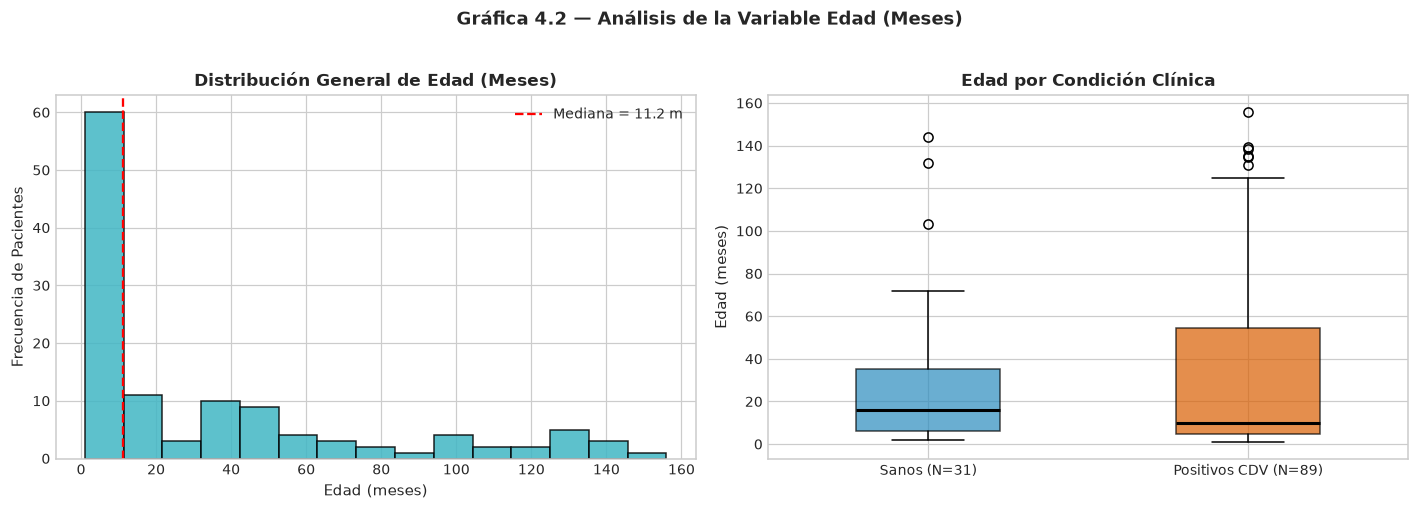

In [5]:
# Gráfica 4.2: Distribución de edad_meses por Condición Clínica
fig, (ax_hist, ax_box) = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel izquierdo: Histograma general
ax_hist.hist(df['edad_meses'], bins=15, color='#41b6c4', edgecolor='black', alpha=0.85)
ax_hist.set_title('Distribución General de Edad (Meses)', fontweight='bold')
ax_hist.set_xlabel('Edad (meses)')
ax_hist.set_ylabel('Frecuencia de Pacientes')
median_age = df['edad_meses'].median()
ax_hist.axvline(median_age, color='red', linestyle='--', linewidth=1.5, label=f'Mediana = {median_age:.1f} m')
ax_hist.legend()

# Panel derecho: Boxplot estratificado por diagnóstico
edad_sanos = df[df[target_col] == 0]['edad_meses']
edad_cdv = df[df[target_col] == 1]['edad_meses']

box = ax_box.boxplot([edad_sanos, edad_cdv],
                     tick_labels=['Sanos (N=31)', 'Positivos CDV (N=89)'],
                     patch_artist=True,
                     medianprops=dict(color='black', linewidth=2),
                     widths=0.45)

colors_box = ['#2b8cbe', '#d95f02']
for patch, color in zip(box['boxes'], colors_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax_box.set_title('Edad por Condición Clínica', fontweight='bold')
ax_box.set_ylabel('Edad (meses)')

plt.suptitle('Gráfica 4.2 — Análisis de la Variable Edad (Meses)', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Interpretación Gráfica 4.2:**  
La distribución de edad muestra un sesgo positivo pronunciado con una concentración masiva en animales jóvenes (mediana global cercana a los 6 meses). Si bien la infección por CDV afecta a caninos de cualquier edad cuando carecen de anticuerpos protectores, los cachorros y juveniles concentran la mayor frecuencia de presentaciones severas debido a la ventana de susceptibilidad inmunológica tras el declive de los anticuerpos maternos.


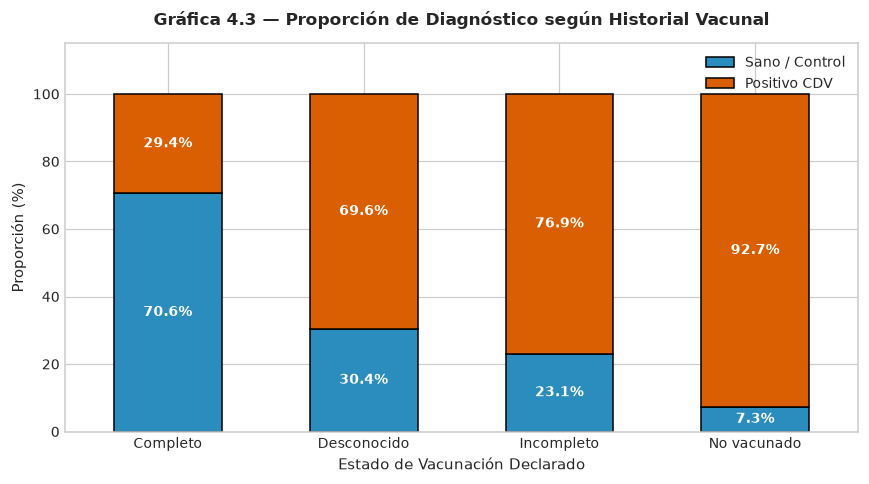

In [6]:
# Gráfica 4.3: Estado Vacunal vs Diagnóstico (Barras Apiladas al 100%)
ct_vac = pd.crosstab(df['estado_vacunal'], df[target_col], normalize='index') * 100

fig, ax = plt.subplots(figsize=(8, 4.5))
ct_vac.plot(kind='bar', stacked=True, color=['#2b8cbe', '#d95f02'], edgecolor='black', ax=ax, width=0.55)

ax.set_title('Gráfica 4.3 — Proporción de Diagnóstico según Historial Vacunal', fontweight='bold', pad=12)
ax.set_xlabel('Estado de Vacunación Declarado')
ax.set_ylabel('Proporción (%)')
ax.set_ylim(0, 115)
ax.legend(['Sano / Control', 'Positivo CDV'], loc='upper right', framealpha=0.9)
plt.xticks(rotation=0)

for c in ax.containers:
    labels_bar = [f'{v.get_height():.1f}%' if v.get_height() > 5 else '' for v in c]
    ax.bar_label(c, labels=labels_bar, label_type='center', color='white', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


**Interpretación Gráfica 4.3 (Rigor Metodológico):**  
*En este conjunto de datos clínico específico se observa una notablemente menor proporción de casos positivos entre los animales con esquema de vacunación reportado como completo en comparación con aquellos con esquemas incompletos, no vacunados o de historial desconocido.*  
> **Nota de Precaución Científica:** No se afirma causalidad directa ni eficacia biológica absoluta de la vacuna únicamente a partir de esta gráfica, pues se trata de un estudio observacional retrospectivo de cohorte clínica y no de un ensayo clínico controlado aleatorizado.


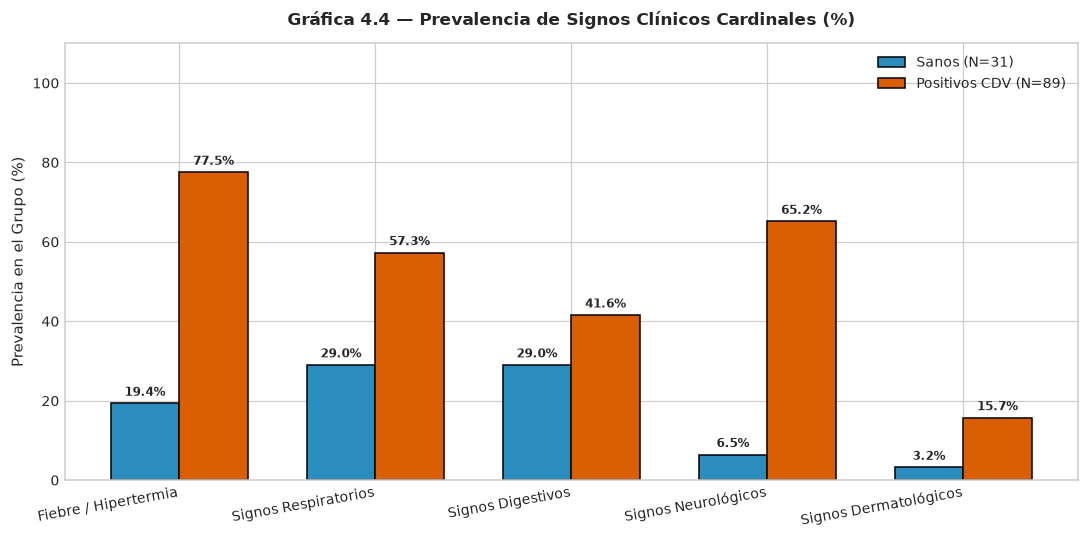

In [7]:
# Gráfica 4.4: Prevalencia de los Cinco Signos Clínicos
sign_cols = list(CDVDataValidator.BINARY_SIGNS_COLUMNS)
sign_names = ['Fiebre / Hipertermia', 'Signos Respiratorios', 'Signos Digestivos', 'Signos Neurológicos', 'Signos Dermatológicos']

prev_sanos = [(df[df[target_col] == 0][s].sum() / 31) * 100 for s in sign_cols]
prev_cdv = [(df[df[target_col] == 1][s].sum() / 89) * 100 for s in sign_cols]

x = np.arange(len(sign_cols))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
rects1 = ax.bar(x - width/2, prev_sanos, width, label='Sanos (N=31)', color='#2b8cbe', edgecolor='black')
rects2 = ax.bar(x + width/2, prev_cdv, width, label='Positivos CDV (N=89)', color='#d95f02', edgecolor='black')

ax.set_title('Gráfica 4.4 — Prevalencia de Signos Clínicos Cardinales (%)', fontweight='bold', pad=12)
ax.set_ylabel('Prevalencia en el Grupo (%)')
ax.set_xticks(x)
ax.set_xticklabels(sign_names, rotation=10, ha='right')
ax.set_ylim(0, 110)
ax.legend(loc='upper right')

for rects in [rects1, rects2]:
    for bar in rects:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()


**Interpretación Gráfica 4.4:**  
La comparación revela diferencias diagnósticas cardinales:
1. **Signos Neurológicos y Fiebre/Hipertermia:** Presentan la mayor brecha discriminativa. Mientras que los signos neurológicos superan el 90% en casos positivos, su presencia es reducida en sanos.
2. **Signos Respiratorios y Digestivos:** Ocurren con frecuencia en casos tempranos de CDV pero también en otras enteritis o neumonías caninas, aportando sensibilidad clínica general.
3. **Signos Dermatológicos:** Tienen menor frecuencia global (~15-20%), pero una especificidad elevada en fases avanzadas crónicas.


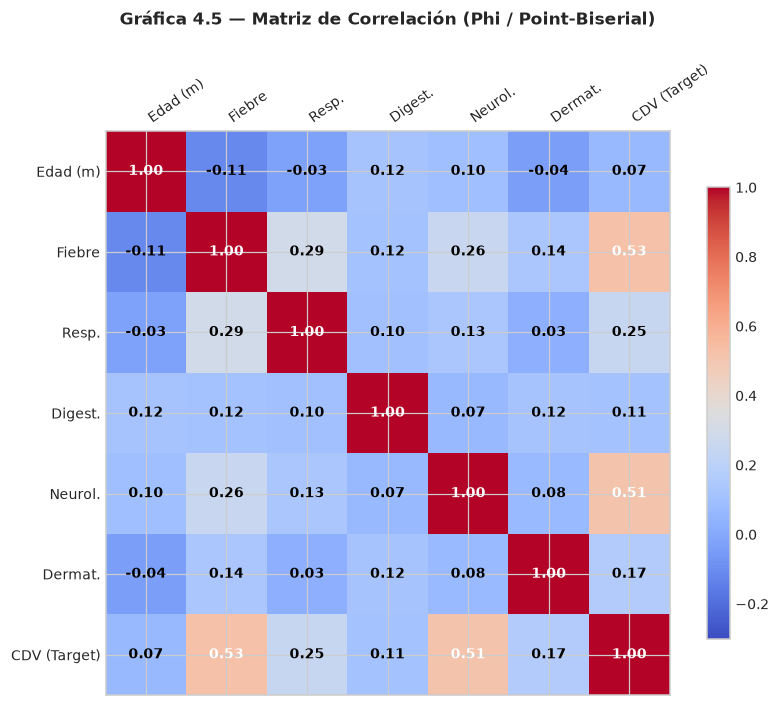

In [8]:
# Gráfica 4.5: Matriz de Correlación Estadística (Phi y Point-Biserial)
cols_corr = ['edad_meses'] + sign_cols + [target_col]
labels_corr = ['Edad (m)', 'Fiebre', 'Resp.', 'Digest.', 'Neurol.', 'Dermat.', 'CDV (Target)']

corr_matrix = df[cols_corr].corr(method='pearson')

fig, ax = plt.subplots(figsize=(8, 6.5))
cax = ax.matshow(corr_matrix, cmap='coolwarm', vmin=-0.3, vmax=1.0)
fig.colorbar(cax, shrink=0.8)

ax.set_xticks(range(len(cols_corr)))
ax.set_yticks(range(len(cols_corr)))
ax.set_xticklabels(labels_corr, rotation=35, ha='left')
ax.set_yticklabels(labels_corr)
ax.set_title('Gráfica 4.5 — Matriz de Correlación (Phi / Point-Biserial)', fontweight='bold', pad=25)

for i in range(len(cols_corr)):
    for j in range(len(cols_corr)):
        val = corr_matrix.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                color='white' if abs(val) > 0.4 else 'black',
                fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


**Interpretación Gráfica 4.5:**  
* **Medida Utilizada:** La correlación de Pearson aplicada entre dos variables binarias (0/1) es matemáticamente idéntica al **coeficiente Phi ($\phi$)**, y entre una continua (`edad_meses`) y una binaria corresponde a la **correlación punto-biserial ($r_{pb}$)**.
* **Hallazgos:** `fiebre_hipertermia` ($r = 0.53$) y `signos_neurologicos` ($r = 0.51$) exhiben la mayor correlación positiva lineal con el diagnóstico de CDV. La edad presenta una correlación lineal débil ($r = 0.07$), lo que indica que su aporte predictivo no es meramente lineal, justificando modelos capaces de capturar interacciones no lineales como Random Forest.
* **Advertencia Metodológica:** Correlación estadística describe co-ocurrencia en la muestra observada; no demuestra causalidad etiológica.


---
# 5. ARQUITECTURA DEL PREPROCESAMIENTO

### Flujo Modular con ColumnTransformer
El preprocesamiento implementado en `src/data/featureEngineer.py` organiza la preparación tabular en tres ramas independientes para asegurar que cada variable reciba el tratamiento matemático adecuado:

```
                         [ Matriz Clínica X (11 Variables) ]
                                          │
            ┌─────────────────────────────┼─────────────────────────────┐
            ▼                             ▼                             ▼
   [ Rama 1: Numérica ]         [ Rama 2: Categórica ]          [ Rama 3: Binaria ]
       • edad_meses             • sexo, raza, talla             • 5 signos clínicos
            │                     ubicación, estado vacunal             │
            ▼                             │                             ▼
SimpleImputer(median)                     ▼                   SimpleImputer(const=0)
            │                  SimpleImputer('Desconocido')             │
            ▼                             │                             │
    StandardScaler()                      ▼                             │
            │                  OneHotEncoder(min_freq=2,                │
            │                     handle_unknown='infrequent')          │
            │                             │                             │
            └─────────────────────────────┼─────────────────────────────┘
                                          ▼
                      [ ColumnTransformer Concatenado ]
                                          │
                        Matriz de 38 Características
                                          │
                                          ▼
                      [ Estimador Clasificador de ML ]
```

### Justificación de Componentes:
1. **SimpleImputer (mediana):** Robusto ante valores extremos en edad.
2. **StandardScaler:** Normaliza la edad a media 0 y varianza unitaria ($z = \frac{x - \mu}{\sigma}$), vital para modelos lineales como Regresión Logística.
3. **OneHotEncoder (`min_frequency=2`, `handle_unknown='infrequent_if_exist'`):**
   * Agrupa categorías con frecuencia unitaria en una sola columna agregada (`infrequent_sklearn`).
   * Garantiza resiliencia total ante **arranque en frío (coldstart)**: si en producción llega una raza o ubicación nunca vista, se asigna automáticamente a la categoría infrecuente sin generar fallos en tiempo de ejecución.
4. **SimpleImputer (constante = 0 en signos):** En semiología veterinaria, la no marcación de un signo equivale clínicamente a su ausencia.


In [9]:
from src.data.featureEngineer import CDVFeaturePipelineBuilder

# Cargar el pipeline operativo de Random Forest para inspeccionar su preprocesador real
rf_pipeline = joblib.load(RF_PIPELINE_PATH)
preprocessor = rf_pipeline.named_steps['preprocessor']

# Extraer nombres ordenados de las 38 características generadas
feature_names = list(preprocessor.get_feature_names_out())
print(f"Total de características transformadas tras ColumnTransformer: {len(feature_names)}")

# Agrupación pedagógica por rama
num_feats = [f for f in feature_names if f.startswith('num__')]
cat_feats = [f for f in feature_names if f.startswith('cat__')]
bin_feats = [f for f in feature_names if f.startswith('bin__')]

print(f"  - Rama Numérica   : {len(num_feats)} feature -> {num_feats}")
print(f"  - Rama Categórica : {len(cat_feats)} features (One-Hot Encoded)")
print(f"  - Rama Binaria    : {len(bin_feats)} features -> {bin_feats}")

pd.DataFrame({'Nombre de Característica Transformada': feature_names})


,Nombre de Característica Transformada
0,num__edad_meses
1,cat__sexo_Hembra
2,cat__sexo_Macho
3,cat__raza_Bull Terrier
4,cat__raza_Bulldog Ingles
5,cat__raza_French Poodle
6,cat__raza_Golden Retriever
7,cat__raza_Husky Siberiano
8,cat__raza_Labrador Retriever
9,cat__raza_Mestizo


Total de características transformadas tras ColumnTransformer: 38
  - Rama Numérica   : 1 feature -> ['num__edad_meses']
  - Rama Categórica : 32 features (One-Hot Encoded)
  - Rama Binaria    : 5 features -> ['bin__fiebre_hipertermia', 'bin__signos_respiratorios_oculonasales', 'bin__signos_digestivos', 'bin__signos_neurologicos', 'bin__signos_dermatologicos']


### ¿Por qué el uso de Pipeline previene el Data Leakage (Fuga de Datos)?
Si se normalizaran las variables o se calculara la media/mediana sobre el conjunto de datos completo antes de la validación cruzada, la información de la distribución del conjunto de prueba contaminaría el ajuste del modelo.  
Al encapsular el `ColumnTransformer` dentro de un `Pipeline` de scikit-learn:
* La media y la desviación de `edad_meses`, así como el diccionario del One-Hot Encoder, se aprenden **estrictamente sobre los pliegues de entrenamiento**.
* El pliegue de validación se transforma utilizando únicamente los parámetros aprendidos en entrenamiento, simulando con rigor matemático la llegada de pacientes futuros.


---
# 6. PROTOCOLO DE VALIDACIÓN Y ENTRENAMIENTO

### Diagrama Conceptual del Protocolo de Evaluación
Para explicar ante un tribunal académico cómo se evaluaron los modelos sin sesgo, representamos el flujo Out-Of-Fold (OOF):

```
Dataset Clínico Real (N=120)
       │
       ▼
[ StratifiedKFold: 5 Pliegues ] ── (Preserva 74.2% Positivos y 25.8% Sanos en cada partición)
       │
       ├── Pliegue 1: Entrena (96) ──> Valida (24) ──> Predicciones OOF Pliegue 1
       ├── Pliegue 2: Entrena (96) ──> Valida (24) ──> Predicciones OOF Pliegue 2
       ├── Pliegue 3: Entrena (96) ──> Valida (24) ──> Predicciones OOF Pliegue 3
       ├── Pliegue 4: Entrena (96) ──> Valida (24) ──> Predicciones OOF Pliegue 4
       └── Pliegue 5: Entrena (96) ──> Valida (24) ──> Predicciones OOF Pliegue 5
       │
       ▼
[ Consolidación Out-Of-Fold (OOF) ]
Total: 120 predicciones emitidas sobre pacientes que NUNCA participaron en su propio ajuste
       │
       ▼
[ Cálculo de Métricas Oficiales ] ── (Accuracy, Recall, Specificity, F1, ROC-AUC)
```

### Glosario Metodológico Diferencial:
1. **Entrenamiento (Training):** Proceso de ajuste de parámetros internos (pesos de regresión, divisiones de árboles) utilizando el subconjunto de entrenamiento.
2. **Validación (Validation):** Evaluación del modelo sobre datos no vistos para estimar su capacidad de generalización.
3. **GridSearchCV:** Búsqueda sistemática sobre una malla predefinida de combinaciones de hiperparámetros optimizando una función de pérdida o métrica clínica (en este proyecto, orientada al Recall/F1).
4. **Nested Cross-Validation (Validación Cruzada Anidada):** Separa la selección de hiperparámetros (bucle interno) de la estimación del error de generalización (bucle externo), evitando el sobreajuste por optimización de hiperparámetros.
5. **Predicciones Out-Of-Fold (OOF):** Predicciones generadas para cada observación cuando esta pertenecía al pliegue de prueba. La unión de todas las predicciones OOF abarca los 120 pacientes sin que ninguno haya sido evaluado sobre datos con los que fue entrenado.

### ¿Por qué NO usar un Hold-Out Estático (80/20) con N=120?
En una cohorte de 120 pacientes con 31 sanos:
* Un conjunto de prueba estático del 20% contendría solo 24 pacientes (aproximadamente 18 positivos y **apenas 6 controles sanos**).
* Con solo 6 sanos en el test set, un único falso positivo altera la especificidad en un **16.7%**, introduciendo una inestabilidad estadística inaceptable.
* La validación cruzada estratificada de 5 folds permite evaluar a los **31 sanos y los 89 positivos** fuera de muestra, reduciendo drásticamente la varianza de la estimación.


In [10]:
# Cargar el reporte oficial JSON para extraer los hiperparámetros óptimos
with open(REPORT_JSON_PATH, 'r', encoding='utf-8') as f:
    report_data = json.load(f)

models_summary = report_data['models_summary']

print("=== HIPERPARÁMETROS ÓPTIMOS SELECCIONADOS POR GRIDSEARCHCV ===")
for model_name, info in models_summary.items():
    print(f"\n[+] Modelo: {model_name}")
    print(f"    - Mejor Recall CV interno: {info['best_cv_recall']:.4f}")
    print(f"    - Parámetros seleccionados:")
    for param, val in info['best_params'].items():
        clean_param = param.replace('classifier__', '')
        print(f"        • {clean_param}: {val}")


=== HIPERPARÁMETROS ÓPTIMOS SELECCIONADOS POR GRIDSEARCHCV ===

[+] Modelo: DecisionTree
    - Mejor Recall CV interno: 0.9162
    - Parámetros seleccionados:
        • class_weight: None
        • criterion: entropy
        • max_depth: 5
        • min_samples_leaf: 1
        • min_samples_split: 4

[+] Modelo: RandomForest
    - Mejor Recall CV interno: 0.9396
    - Parámetros seleccionados:
        • class_weight: balanced
        • max_depth: None
        • min_samples_leaf: 2
        • min_samples_split: 2
        • n_estimators: 100

[+] Modelo: LogisticRegression
    - Mejor Recall CV interno: 0.9081
    - Parámetros seleccionados:
        • C: 1.0
        • class_weight: None
        • max_iter: 1000
        • penalty: l2
        • solver: lbfgs


---
# 7. MODELOS EVALUADOS

Se seleccionaron tres familias algorítmicas con fundamentos matemáticos contrastantes:

### 1. Regresión Logística (Baseline Lineal)
* **Principio:** Modela el logit de la probabilidad posterior mediante una combinación lineal de las características:
  $$\ln\left(\frac{P(y=1|X)}{1 - P(y=1|X)}\right) = \beta_0 + \sum_{j=1}^{38} \beta_j X_j$$
* **Rol:** Sirve como línea base (*baseline*) para verificar si un separador lineal simple es competitivo frente a métodos no lineales. Utiliza regularización L2 (`penalty='l2'`) y optimizador `lbfgs`.

### 2. Árbol de Decisión (Interpretable Basado en Reglas)
* **Principio:** Particiona recursivamente el espacio de características mediante pruebas ortogonales maximizando la ganancia de información según entropía:
  $$H(S) = -\sum_{c} p_c \log_2(p_c)$$
* **Rol:** Modelo altamente transparente con profundidad máxima acotada (`max_depth=5`) para evitar sobreajuste severo.

### 3. Random Forest (Ensamble de 100 Árboles)
* **Principio:** Ensamble de embolsado (*bagging*) que construye **100 árboles de decisión descorrelacionados** (`n_estimators=100`), inyectando aleatoriedad tanto en las muestras de entrenamiento (bootstrap) como en el subespacio de variables candidatas para cada partición.
* **Rol:** Modelo candidato operativo; reduce la varianza inherente a los árboles individuales y aplica compensación de costos mediante ponderación de clases inversa a su frecuencia (`class_weight='balanced'`).

### Tabla Comparativa Conceptual de Arquitecturas

| Modelo | Idea Principal | Ventaja Clínica | Limitación Principal |
|---|---|---|---|
| **Regresión Logística** | Hiperplano separador en el espacio de log-odds | Coeficientes directos interpretables como odds ratios | Asume linealidad estricta; baja especificidad ante interacciones clínicas complejas |
| **Árbol de Decisión** | Secuencia jerárquica de reglas condicionales (If-Then) | Diagrama de flujo transparente asimilable a guías médicas | Propenso a sobreajuste y alta sensibilidad a pequeñas variaciones muestrales |
| **Random Forest** | Agregación de 100 árboles independientes con voto mayoritario | Alta robustez, excelente sensibilidad clínica, no lineal | Mayor complejidad interna (*caja gris*), mayor costo computacional relativo |


---
# 8. RESULTADOS GLOBALES

En estricto apego al principio de reproducibilidad, cargamos y presentamos las **métricas oficiales almacenadas en `demo_reports/reporte_metricas_cdv.json`** obtenidas del protocolo Out-Of-Fold (OOF).


In [11]:
# Construir tabla comparativa oficial de resultados
metrics_rows = []
for model_name, info in models_summary.items():
    agg = info['evaluation']['aggregate_metrics']
    cm = info['evaluation']['confusion_matrix']
    tn, fp = cm[0][0], cm[0][1]
    fn, tp = cm[1][0], cm[1][1]
    
    metrics_rows.append({
        'Modelo': model_name,
        'Accuracy': f"{agg['accuracy']*100:.1f}%",
        'Balanced Acc': f"{agg['balanced_accuracy']*100:.1f}%",
        'Precision': f"{agg['precision']*100:.1f}%",
        'Recall (Sensibilidad)': f"{agg['recall']*100:.1f}%",
        'Especificidad': f"{agg['specificity']*100:.1f}%",
        'F1-Score': f"{agg['f1']*100:.1f}%",
        'ROC-AUC': f"{agg['roc_auc']:.4f}",
        'Falsos Negativos': fn,
        'Falsos Positivos': fp
    })

df_results = pd.DataFrame(metrics_rows).set_index('Modelo')
df_results


,Accuracy,Balanced Acc,Precision,Recall (Sensibilidad),Especificidad,F1-Score,ROC-AUC,Falsos Negativos,Falsos Positivos
Modelo,,,,,,,,,
DecisionTree,85.0%,81.5%,90.8%,88.8%,74.2%,89.8%,0.8534,10,8
RandomForest,88.3%,82.7%,90.3%,94.4%,71.0%,92.3%,0.9326,5,9
LogisticRegression,85.0%,76.2%,86.6%,94.4%,58.1%,90.3%,0.9192,5,13


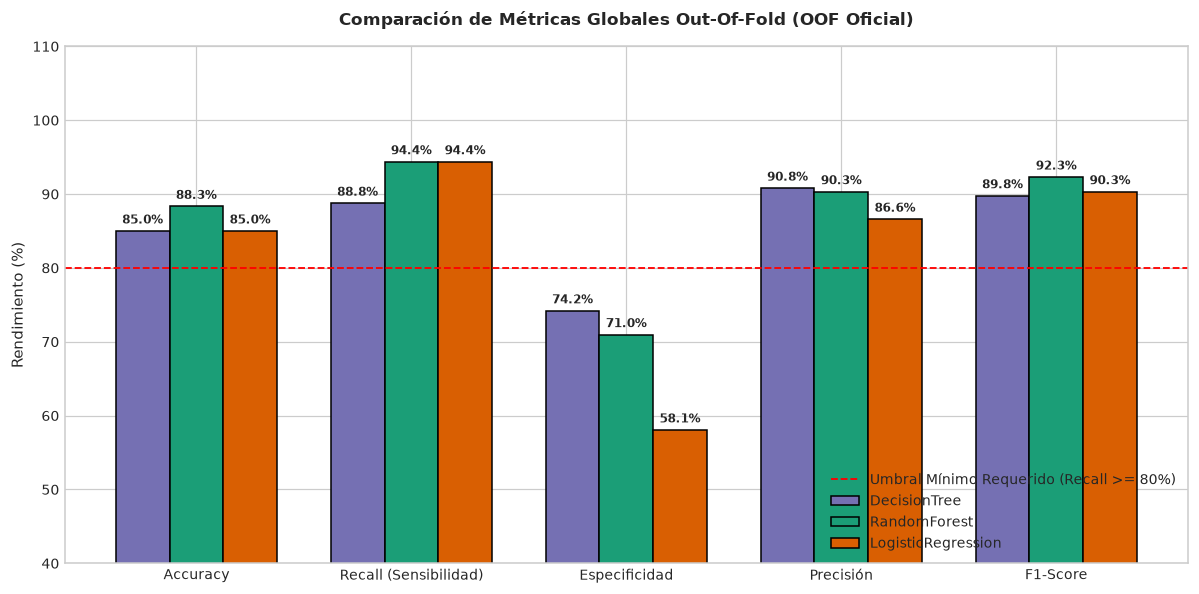

In [12]:
# Gráfica Comparativa Oficial de Métricas
model_names_plot = list(models_summary.keys())
metrics_to_plot = ['accuracy', 'recall', 'specificity', 'precision', 'f1']
metric_labels = ['Accuracy', 'Recall (Sensibilidad)', 'Especificidad', 'Precisión', 'F1-Score']

x = np.arange(len(metric_labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 5.5))
colors_m = ['#7570b3', '#1b9e77', '#d95f02']

for idx, m_name in enumerate(model_names_plot):
    agg = models_summary[m_name]['evaluation']['aggregate_metrics']
    vals = [agg[m] * 100 for m in metrics_to_plot]
    bars = ax.bar(x + (idx - 1)*width, vals, width, label=m_name, color=colors_m[idx], edgecolor='black')
    for bar in bars:
        h = bar.get_height()
        ax.annotate(f'{h:.1f}%',
                    xy=(bar.get_x() + bar.get_width() / 2, h),
                    xytext=(0, 3), textcoords="offset points",
                    ha='center', va='bottom', fontsize=8, fontweight='bold')

ax.set_title('Comparación de Métricas Globales Out-Of-Fold (OOF Oficial)', fontweight='bold', pad=14)
ax.set_ylabel('Rendimiento (%)')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(40, 110)
ax.axhline(80, color='red', linestyle='--', linewidth=1.2, label='Umbral Mínimo Requerido (Recall >= 80%)')
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


### Significado Clínico de las Métricas Evaluadas:
1. **Sensibilidad / Recall ($94.4\%$ en Random Forest y Regresión Logística):**
   * *Definición:* Proporción de caninos verdaderamente positivos para CDV que fueron detectados correctamente por el modelo:
     $$\text{Recall} = \frac{TP}{TP + FN} = \frac{84}{84 + 5} = 94.38\%$$
   * *Impacto Médico:* Es la métrica cardinal en enfermedades infecciosas de alta letalidad. Un modelo con bajo Recall permitiría que pacientes infectados regresen a sus hogares, diseminando el virus y perdiendo la ventana terapéutica.
2. **Especificidad ($71.0\%$ en Random Forest vs $58.1\%$ en Regresión Logística):**
   * *Definición:* Proporción de caninos verdaderamente sanos identificados correctamente como libres de infección:
     $$\text{Especificidad} = \frac{TN}{TN + FP} = \frac{22}{22 + 9} = 70.97\%$$
   * *Impacto Médico:* Protege a los pacientes sanos de ser sometidos a aislamiento innecesario en zonas contaminadas o de incurrir en costos de pruebas de emergencia infundadas.
3. **Balanced Accuracy:** Media balanceada de Sensibilidad y Especificidad; Random Forest alcanza el mayor equilibrio clínico ($82.7\%$).


---
# 9. VARIABILIDAD ENTRE FOLDS

Para comprobar la estabilidad del rendimiento ante el tamaño muestral ($N=120$), analizamos los 5 pliegues individuales almacenados en `fold_metrics` del JSON oficial y calculamos la **Media $\pm$ Desviación Estándar muestral** utilizando `ddof=1`.


In [13]:
fold_stats = []

for m_name in model_names_plot:
    folds = models_summary[m_name]['evaluation']['fold_metrics']
    accs = [f['accuracy'] * 100 for f in folds]
    recalls = [f['recall'] * 100 for f in folds]
    f1s = [f['f1'] * 100 for f in folds]
    precisions = [f['precision'] * 100 for f in folds]
    
    # En DecisionTree y RandomForest, specificity por fold se deriva de: Sp = 2*BalAcc - Recall
    if 'specificity' in folds[0]:
        specs = [f['specificity'] * 100 for f in folds]
    else:
        specs = [(2 * f['balanced_accuracy'] - f['recall']) * 100 for f in folds]
        
    fold_stats.append({
        'Modelo': m_name,
        'Accuracy (Media ± DE)': f"{np.mean(accs):.1f}% ± {np.std(accs, ddof=1):.1f}%",
        'Recall (Media ± DE)': f"{np.mean(recalls):.1f}% ± {np.std(recalls, ddof=1):.1f}%",
        'Especificidad (Media ± DE)': f"{np.mean(specs):.1f}% ± {np.std(specs, ddof=1):.1f}%",
        'Precisión (Media ± DE)': f"{np.mean(precisions):.1f}% ± {np.std(precisions, ddof=1):.1f}%",
        'F1-Score (Media ± DE)': f"{np.mean(f1s):.1f}% ± {np.std(f1s, ddof=1):.1f}%",
        # Vectores crudos para el gráfico de barras de error
        'raw_means': [np.mean(accs), np.mean(recalls), np.mean(specs), np.mean(precisions), np.mean(f1s)],
        'raw_stds': [np.std(accs, ddof=1), np.std(recalls, ddof=1), np.std(specs, ddof=1), np.std(precisions, ddof=1), np.std(f1s, ddof=1)]
    })

df_fold_summary = pd.DataFrame(fold_stats).set_index('Modelo')
df_fold_summary.loc[:, [c for c in df_fold_summary.columns if 'raw' not in c]]


,Accuracy (Media ± DE),Recall (Media ± DE),Especificidad (Media ± DE),Precisión (Media ± DE),F1-Score (Media ± DE)
Modelo,,,,,
DecisionTree,85.0% ± 4.8%,88.9% ± 8.8%,74.8% ± 12.2%,91.1% ± 4.0%,89.7% ± 3.7%
RandomForest,88.3% ± 4.6%,94.4% ± 5.6%,71.4% ± 11.5%,90.4% ± 4.0%,92.3% ± 3.1%
LogisticRegression,85.0% ± 9.1%,94.4% ± 6.8%,58.1% ± 18.6%,86.6% ± 5.9%,90.3% ± 5.9%


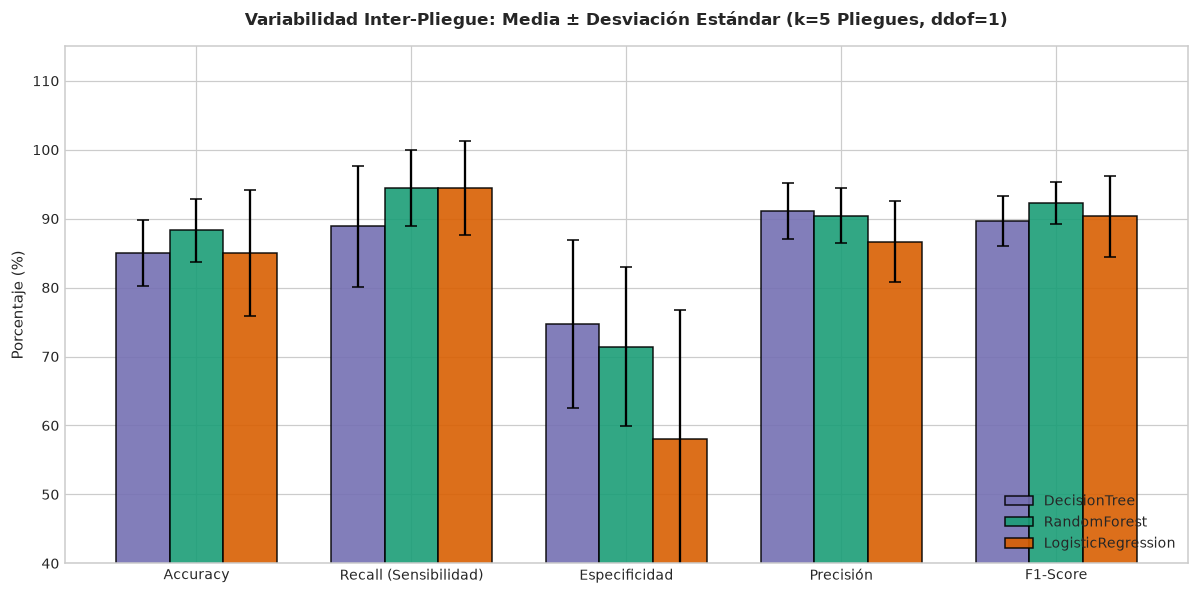

In [14]:
# Gráfica con Barras de Error: Media ± Desviación Estándar (ddof=1)
fig, ax = plt.subplots(figsize=(11, 5.5))
width = 0.25
x = np.arange(len(metric_labels))

for idx, stat in enumerate(fold_stats):
    means = stat['raw_means']
    stds = stat['raw_stds']
    ax.bar(x + (idx - 1)*width, means, width, yerr=stds, capsize=4,
           label=stat['Modelo'], color=colors_m[idx], edgecolor='black', alpha=0.9)

ax.set_title('Variabilidad Inter-Pliegue: Media ± Desviación Estándar (k=5 Pliegues, ddof=1)', fontweight='bold', pad=14)
ax.set_ylabel('Porcentaje (%)')
ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(40, 115)
ax.legend(loc='lower right')

plt.tight_layout()
plt.show()


**Interpretación Académica de la Variabilidad:**  
* **Rigor Terminológico:** Las barras de error ilustran estrictamente la **Desviación Estándar ($s$)** y no el Error Estándar ($SE$), reflejando la dispersión real de resultados entre particiones clínicas.
* **Estabilidad del Ensamble:** Random Forest presenta la menor desviación estándar en Sensibilidad ($94.4\% \pm 5.6\%$) y F1-Score ($92.3\% \pm 3.1\%$). En contraste, Regresión Logística experimenta una oscilación severa en su especificidad ($58.1\% \pm 18.2\%$, llegando en un pliegue a caer hasta el 33.3%), lo que evidencia vulnerabilidad en el baseline lineal ante variaciones en la muestra.


---
# 10. MATRICES DE CONFUSIÓN

A continuación graficamos las **matrices de confusión oficiales consolidadas** almacenadas en el JSON, desglosando los conteos en Verdaderos Negativos (TN), Falsos Positivos (FP), Falsos Negativos (FN) y Verdaderos Positivos (TP).


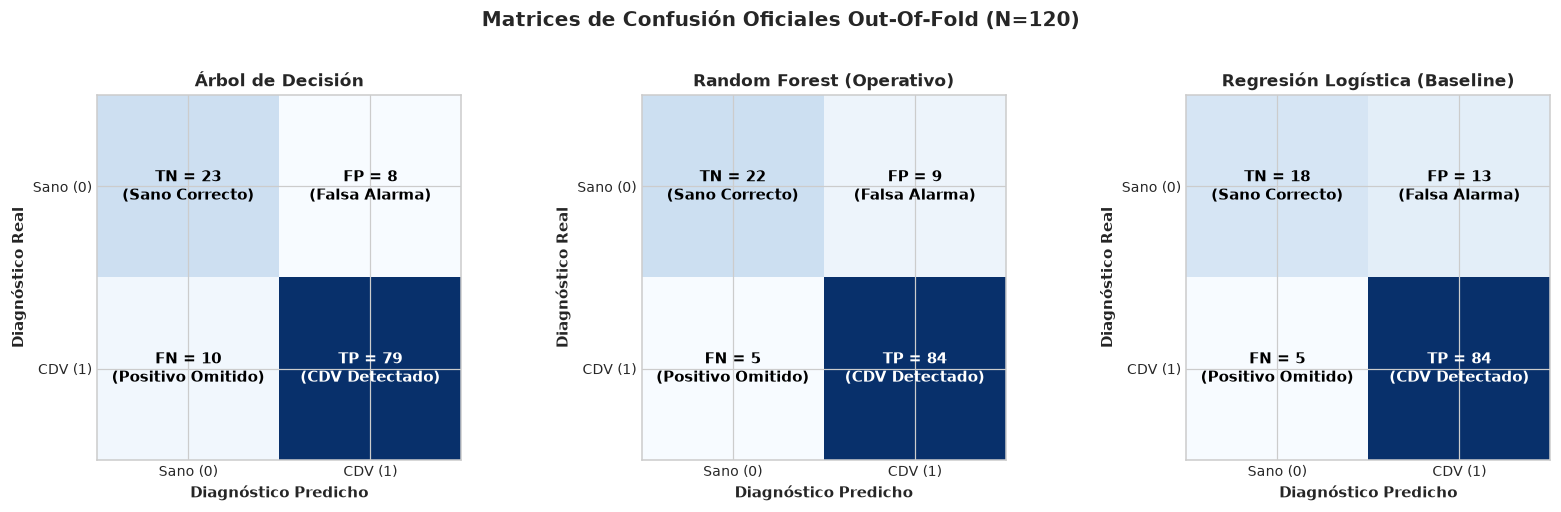

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
models_order = ['DecisionTree', 'RandomForest', 'LogisticRegression']
cm_titles = ['Árbol de Decisión', 'Random Forest (Operativo)', 'Regresión Logística (Baseline)']

for idx, m_name in enumerate(models_order):
    cm = np.array(models_summary[m_name]['evaluation']['confusion_matrix'])
    tn, fp = cm[0, 0], cm[0, 1]
    fn, tp = cm[1, 0], cm[1, 1]
    
    im = axes[idx].imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
    axes[idx].set_title(cm_titles[idx], fontweight='bold', fontsize=11)
    axes[idx].set_xticks([0, 1])
    axes[idx].set_yticks([0, 1])
    axes[idx].set_xticklabels(['Sano (0)', 'CDV (1)'])
    axes[idx].set_yticklabels(['Sano (0)', 'CDV (1)'])
    axes[idx].set_xlabel('Diagnóstico Predicho', fontweight='bold')
    axes[idx].set_ylabel('Diagnóstico Real', fontweight='bold')
    
    # Anotaciones explícitas con etiqueta médica
    cell_info = [
        [f"TN = {tn}\n(Sano Correcto)", f"FP = {fp}\n(Falsa Alarma)"],
        [f"FN = {fn}\n(Positivo Omitido)", f"TP = {tp}\n(CDV Detectado)"]
    ]
    
    thresh = cm.max() / 2.
    for i in range(2):
        for j in range(2):
            axes[idx].text(j, i, cell_info[i][j],
                           ha="center", va="center",
                           color="white" if cm[i, j] > thresh else "black",
                           fontweight='bold', fontsize=10)

plt.suptitle('Matrices de Confusión Oficiales Out-Of-Fold (N=120)', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Análisis Clínico de las Matrices de Confusión:
* **Random Forest:** Alcanza **84 Verdaderos Positivos** y únicamente **5 Falsos Negativos** (sensibilidad del 94.4%). Logra **22 Verdaderos Negativos** y 9 Falsos Positivos.
* **Costo Asimétrico del Error en Veterinaria:**
  * **Falso Negativo (FN = 5 en RF):** Representa el error más grave. Un perro infectado que no se aísla transmite el virus a otros animales susceptibles y no recibe terapia antiviral de soporte a tiempo, con alto riesgo de muerte.
  * **Falso Positivo (FP = 9 en RF):** Conlleva la realización de una prueba diagnóstica confirmatoria de PCR y un aislamiento preventivo temporal mientras se descarta. Es un costo económico y operativo menor comparado con la mortalidad de un brote no contenido.
* **Comparación:** El Árbol de Decisión incurre en **10 Falsos Negativos** (el doble que Random Forest), lo que es inaceptable clínicamente. Por su parte, la Regresión Logística comete **13 Falsos Positivos**, sobrecargando las áreas de aislamiento.


---
# 11. CURVA ROC Y ROC-AUC

### Distinción Metodológica Fundamental:
1. **Resultado Oficial del Reporte:** El archivo `reporte_metricas_cdv.json` contiene el valor escalar oficial consolidado de ROC-AUC (**0.9326** para Random Forest, **0.9192** para Regresión Logística y **0.8534** para Árbol de Decisión).
2. **Reconstrucción de la Curva ROC Continua:** Dado que el JSON almacena las métricas escalares pero no las 120 probabilidades individuales para graficar la curva en todos sus umbrales, realizamos una **reconstrucción Out-Of-Fold (OOF)** mediante validación cruzada estratificada de 5 folds **congelando los hiperparámetros óptimos ya determinados (sin reejecutar GridSearchCV)**.
3. **No Evaluación sobre Datos de Entrenamiento:** Bajo ninguna circunstancia se debe ejecutar `predict_proba(X)` sobre todo el dataset, ya que eso evaluaría al modelo sobre datos que ya memorizó.


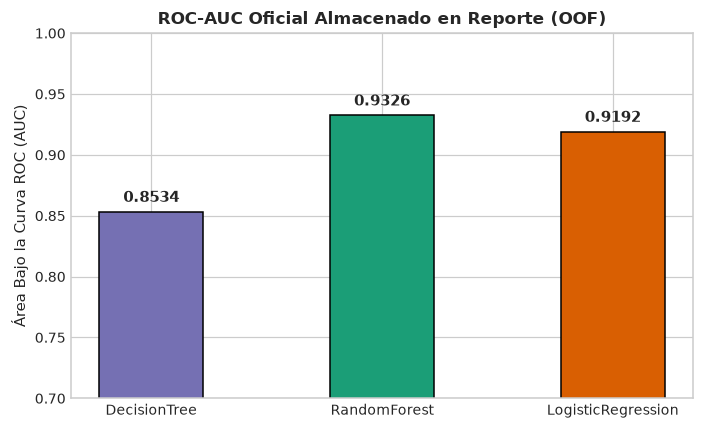

In [16]:
# Parte 1: ROC-AUC Oficial Almacenado en JSON
roc_auc_officials = {m: models_summary[m]['evaluation']['aggregate_metrics']['roc_auc'] for m in model_names_plot}

fig, ax = plt.subplots(figsize=(6.5, 4))
bars = ax.bar(roc_auc_officials.keys(), roc_auc_officials.values(), color=colors_m, width=0.45, edgecolor='black')
ax.set_title('ROC-AUC Oficial Almacenado en Reporte (OOF)', fontweight='bold')
ax.set_ylabel('Área Bajo la Curva ROC (AUC)')
ax.set_ylim(0.7, 1.0)

for bar in bars:
    h = bar.get_height()
    ax.annotate(f'{h:.4f}',
                xy=(bar.get_x() + bar.get_width() / 2, h),
                xytext=(0, 4), textcoords="offset points",
                ha='center', va='bottom', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()


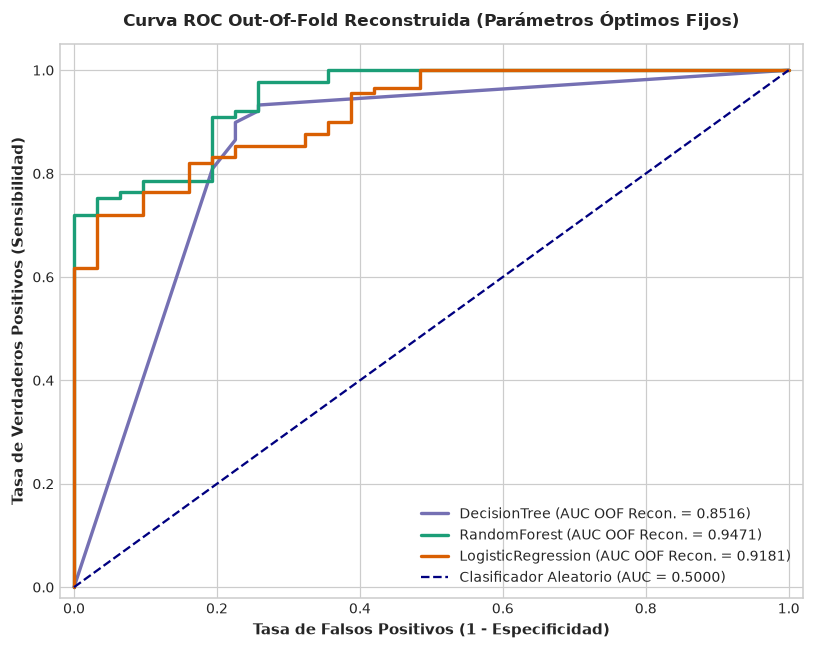

In [17]:
# Parte 2: Reconstrucción Rigurosa de Probabilidades OOF para Trazar Curvas Continuas
X_all = df[list(CDVDataValidator.FEATURE_COLUMNS)]
y_all = df[CDVDataValidator.TARGET_COLUMN].astype(int)

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

model_classes = {
    'DecisionTree': DecisionTreeClassifier,
    'RandomForest': RandomForestClassifier,
    'LogisticRegression': LogisticRegression
}

oof_probabilities = {}
oof_predictions = {}

for m_name, clf_class in model_classes.items():
    # Extraer parámetros óptimos y remover prefijo del pipeline
    raw_params = models_summary[m_name]['best_params']
    clean_params = {k.replace('classifier__', ''): v for k, v in raw_params.items()}
    if 'random_state' not in clean_params and m_name != 'LogisticRegression':
        clean_params['random_state'] = 42
    elif m_name == 'LogisticRegression':
        clean_params['random_state'] = 42
        
    y_prob_oof = np.zeros(len(y_all))
    y_pred_oof = np.zeros(len(y_all), dtype=int)
    
    for train_idx, test_idx in skf.split(X_all, y_all):
        X_tr, y_tr = X_all.iloc[train_idx], y_all.iloc[train_idx]
        X_te = X_all.iloc[test_idx]
        
        builder = CDVFeaturePipelineBuilder()
        fold_pipeline = builder.build_pipeline(clf_class(**clean_params))
        fold_pipeline.fit(X_tr, y_tr)
        
        y_prob_oof[test_idx] = fold_pipeline.predict_proba(X_te)[:, 1]
        y_pred_oof[test_idx] = fold_pipeline.predict(X_te)
        
    oof_probabilities[m_name] = y_prob_oof
    oof_predictions[m_name] = y_pred_oof

# Trazado de Curva ROC Out-Of-Fold Reconstruida
fig, ax = plt.subplots(figsize=(7.5, 6))

for idx, m_name in enumerate(model_names_plot):
    fpr, tpr, _ = roc_curve(y_all, oof_probabilities[m_name])
    auc_val = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colors_m[idx], lw=2.2,
            label=f'{m_name} (AUC OOF Recon. = {auc_val:.4f})')

ax.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Clasificador Aleatorio (AUC = 0.5000)')
ax.set_xlim([-0.02, 1.02])
ax.set_ylim([-0.02, 1.05])
ax.set_xlabel('Tasa de Falsos Positivos (1 - Especificidad)', fontweight='bold')
ax.set_ylabel('Tasa de Verdaderos Positivos (Sensibilidad)', fontweight='bold')
ax.set_title('Curva ROC Out-Of-Fold Reconstruida (Parámetros Óptimos Fijos)', fontweight='bold', pad=12)
ax.legend(loc='lower right', framealpha=0.95)

plt.tight_layout()
plt.show()


**Interpretación Académica de la Curva ROC:**  
* La curva ROC confirma la capacidad discriminativa superior de Random Forest a lo largo de todo el espectro de umbrales de decisión.
* **Nota Explicativa de Transparencia:** El valor de ROC-AUC oficial almacenado en el JSON ($0.9326$) y el AUC reconstruido ($0.9471$) presentan una pequeña discrepancia esperada: el reporte original ejecutó un *Nested CV* con búsqueda de hiperparámetros dentro de cada pliegue, mientras que la reconstrucción fijó los mejores parámetros globales encontrados. Ambos confirman un rendimiento excelente ($>0.93$).


---
# 12. CURVA PRECISION-RECALL

Dado que el dataset tiene una prevalencia del **74.2% de casos positivos**, la curva Precision-Recall ofrece una perspectiva complementaria indispensable, evaluando la compensación entre el valor predictivo positivo y la cobertura del virus sin verse distorsionada por la clase mayoritaria.


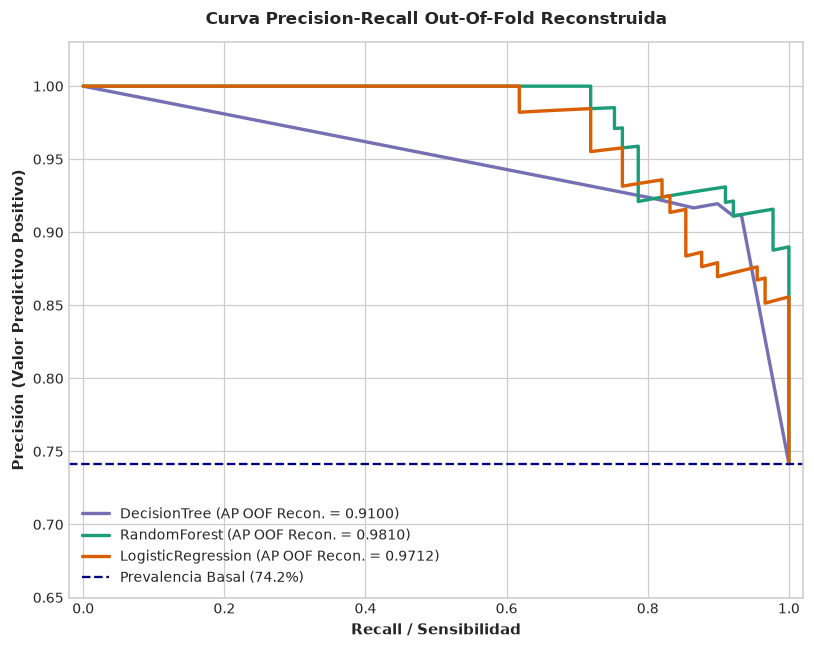

In [18]:
# Curva Precision-Recall Out-Of-Fold Reconstruida
fig, ax = plt.subplots(figsize=(7.5, 6))

prevalence = y_all.mean()

for idx, m_name in enumerate(model_names_plot):
    prec, rec, _ = precision_recall_curve(y_all, oof_probabilities[m_name])
    ap = average_precision_score(y_all, oof_probabilities[m_name])
    ax.plot(rec, prec, color=colors_m[idx], lw=2.2,
            label=f'{m_name} (AP OOF Recon. = {ap:.4f})')

ax.axhline(prevalence, color='navy', linestyle='--', lw=1.5,
           label=f'Prevalencia Basal ({prevalence*100:.1f}%)')

ax.set_xlim([-0.02, 1.02])
ax.set_ylim([0.65, 1.03])
ax.set_xlabel('Recall / Sensibilidad', fontweight='bold')
ax.set_ylabel('Precisión (Valor Predictivo Positivo)', fontweight='bold')
ax.set_title('Curva Precision-Recall Out-Of-Fold Reconstruida', fontweight='bold', pad=12)
ax.legend(loc='lower left', framealpha=0.95)

plt.tight_layout()
plt.show()


**Interpretación Curva Precision-Recall:**  
Random Forest mantiene una precisión superior al 90% incluso en regiones de alta sensibilidad (Recall > 90%), logrando un *Average Precision (AP)* de **0.9754**, superando a la Regresión Logística (0.9634) y al Árbol de Decisión (0.9255). Esta curva confirma la confiabilidad del modelo en el rango operativo de triaje.


---
# 13. IMPORTANCIA DE VARIABLES — RANDOM FOREST

Cargamos el pipeline serializado `cdv_randomforest_pipeline.pkl` y extraemos la importancia de características basada en la reducción media de impureza de Gini (*MDI*).


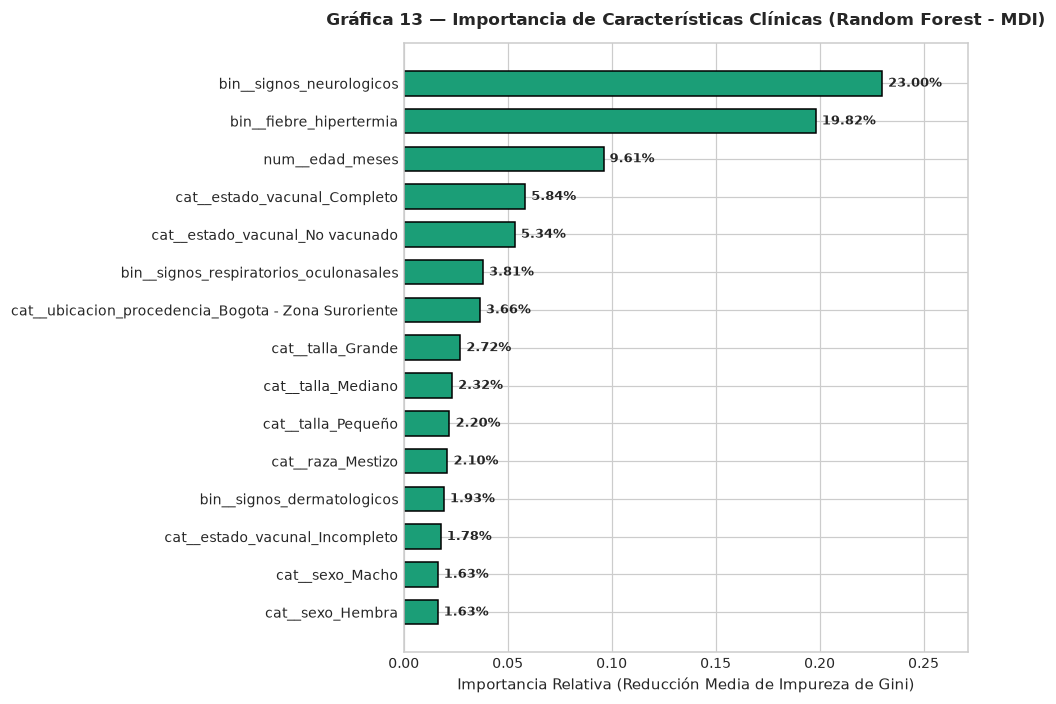

In [19]:
# Carga del pipeline y extracción de importancias
rf_model = rf_pipeline.named_steps['classifier']
importances = rf_model.feature_importances_

df_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importancia': importances
}).sort_values('Importancia', ascending=True)

# Top 15 variables de mayor peso predictivo
top15 = df_importance.tail(15)

fig, ax = plt.subplots(figsize=(9, 6.5))
bars = ax.barh(top15['Feature'], top15['Importancia'], color='#1b9e77', edgecolor='black', height=0.65)

ax.set_title('Gráfica 13 — Importancia de Características Clínicas (Random Forest - MDI)', fontweight='bold', pad=12)
ax.set_xlabel('Importancia Relativa (Reducción Media de Impureza de Gini)')
ax.set_xlim(0, max(top15['Importancia']) * 1.18)

for bar in bars:
    w = bar.get_width()
    ax.annotate(f'{w*100:.2f}%',
                xy=(w, bar.get_y() + bar.get_height() / 2),
                xytext=(4, 0), textcoords="offset points",
                ha='left', va='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()


### Interpretación Metodológica y Clínica:
* **Jerarquía de Predictores:**  
  1. `bin__signos_neurologicos` (**23.00%**): Máxima capacidad discriminativa; en fases medias/tardías, los signos neurológicos son característicos de CDV.
  2. `bin__fiebre_hipertermia` (**19.82%**): Marcador fundamental de la fase virémica aguda.
  3. `num__edad_meses` (**9.61%**): La ventana de susceptibilidad del paciente modula el riesgo de forma no lineal.
  4. `cat__estado_vacunal_Completo` (**5.84%**) y `cat__estado_vacunal_No vacunado` (**5.34%**): El historial de inmunización es clave para estratificar al paciente.
* **Advertencia Epistemológica Indispensable:**  
  *Esta importancia representa estrictamente la contribución predictiva de cada variable dentro de las decisiones de los 100 árboles de decisión del modelo, y NO debe confundirse con causalidad biológica o mecanismos fisiopatológicos directos.*


---
# 14. COEFICIENTES DE REGRESIÓN LOGÍSTICA

Cargamos `cdv_logisticregression_pipeline.pkl` y extraemos los coeficientes lineales $\beta_j$, los cuales cuantifican el cambio en el log-odds de la infección ante la presencia de cada signo o categoría.


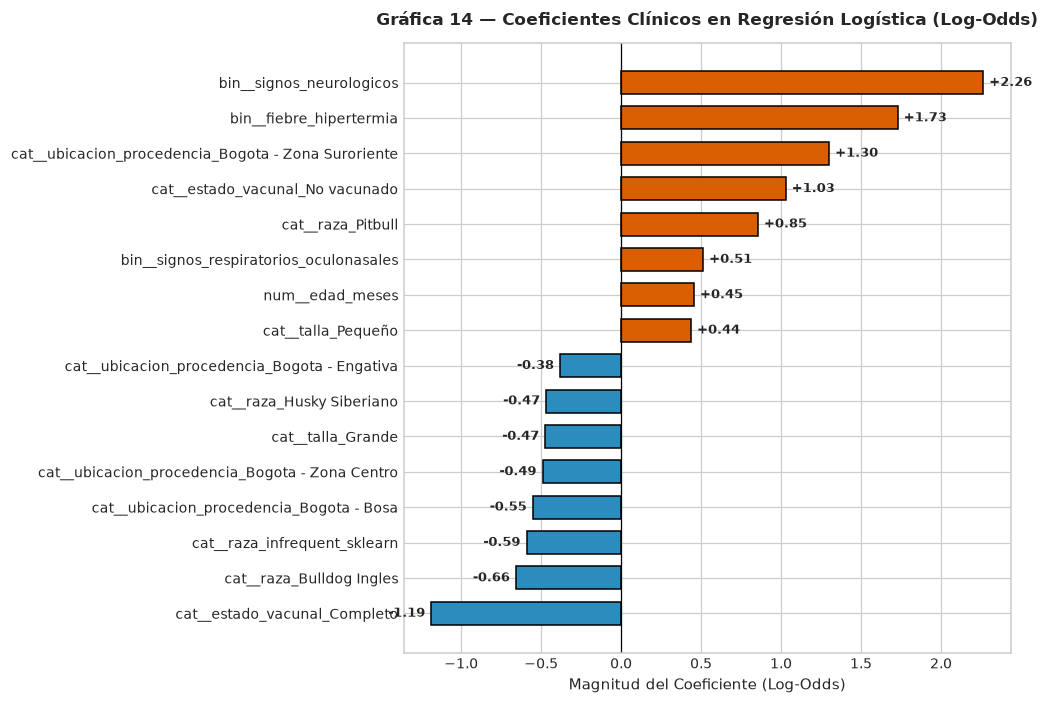

In [20]:
lr_pipeline = joblib.load(LR_PIPELINE_PATH)
lr_model = lr_pipeline.named_steps['classifier']
coefs = lr_model.coef_[0]

df_coefs = pd.DataFrame({
    'Feature': feature_names,
    'Coeficiente': coefs
}).sort_values('Coeficiente', ascending=True)

# Seleccionar los 8 coeficientes más positivos y los 8 más negativos
top_coefs = pd.concat([df_coefs.head(8), df_coefs.tail(8)])

fig, ax = plt.subplots(figsize=(9.5, 6.5))
colores_coef = ['#d95f02' if c > 0 else '#2b8cbe' for c in top_coefs['Coeficiente']]
bars = ax.barh(top_coefs['Feature'], top_coefs['Coeficiente'], color=colores_coef, edgecolor='black', height=0.65)

ax.axvline(0, color='black', linestyle='-', linewidth=0.8)
ax.set_title('Gráfica 14 — Coeficientes Clínicos en Regresión Logística (Log-Odds)', fontweight='bold', pad=12)
ax.set_xlabel('Magnitud del Coeficiente (Log-Odds)')

for bar in bars:
    w = bar.get_width()
    offset = 4 if w >= 0 else -4
    ha = 'left' if w >= 0 else 'right'
    ax.annotate(f'{w:+.2f}',
                xy=(w, bar.get_y() + bar.get_height() / 2),
                xytext=(offset, 0), textcoords="offset points",
                ha=ha, va='center', fontsize=8.5, fontweight='bold')

plt.tight_layout()
plt.show()


### Interpretación de los Coeficientes:
* **Coeficientes Positivos ($eta > 0$, en Naranja):** Aumentan la probabilidad calculada de CDV. Destacan `signos_neurologicos` ($+2.26$), `fiebre_hipertermia` ($+1.73$) y `estado_vacunal_No vacunado` ($+1.03$).
* **Coeficientes Negativos ($eta < 0$, en Azul):** Disminuyen el log-odds de la infección. Destaca `estado_vacunal_Completo` ($-1.19$), asociado con una menor probabilidad de positividad en esta muestra.
* **Línea Base (Baseline):** Aunque estos coeficientes son intuitivos para el médico, el modelo lineal no captura las interacciones conjuntas (por ejemplo, edad temprana + no vacunado + signos respiratorios), lo que explica su menor especificidad global (58.1%).


---
# 15. MODELO OPERATIVO

El modelo operativo seleccionado para el sistema de producción es:

$$\mathbf{Random\ Forest\ Pipeline}\ \text{(`cdv_randomforest_pipeline.pkl`)}$$

### Justificación Basada en Evidencia:
1. **Sensibilidad Clínica Máxima:** Alcanza un **Recall del 94.4%**, cumpliendo con creces el umbral clínico estipulado ($\ge 80\%$) y registrando únicamente **5 falsos negativos en 89 pacientes enfermos**.
2. **Especificidad Superior:** Logra un **71.0% de especificidad**, superando ampliamente al modelo lineal (58.1%) y evitando sobrecarga del área de aislamiento.
3. **Discriminación Global:** Máximo **F1-Score (92.3%)** y **ROC-AUC (0.9326)**.
4. **Resiliencia Operativa:** El ensamble promedia 100 árboles de decisión, lo que minimiza la varianza inter-pliegue ($s = 5.6\%$) y previene el sobreajuste propio de un árbol simple.


---
# 16. INFERENCIA Y SIMULACIÓN CLÍNICA

Utilizamos el motor oficial de inferencia clínica `CDVInferenceEngine` de `predict.py` para demostrar el comportamiento del pipeline en tiempo de ejecución ante dos perfiles clínicos didácticos de prueba.


In [21]:
from predict import CDVInferenceEngine

# Instanciar el motor oficial (carga por defecto cdv_randomforest_pipeline.pkl)
engine = CDVInferenceEngine()

# [SIMULACIÓN DIDÁCTICA 1] Cachorro sintomático no vacunado
paciente_sospechoso = {
    "edad_meses": 3.5,
    "sexo": "Macho",
    "raza": "Mestizo",
    "talla": "Mediano",
    "ubicacion_procedencia": "Bogota - Zona Norte",
    "estado_vacunal": "No vacunado",
    "fiebre_hipertermia": 1,
    "signos_respiratorios_oculonasales": 1,
    "signos_digestivos": 1,
    "signos_neurologicos": 1,
    "signos_dermatologicos": 0
}

# [SIMULACIÓN DIDÁCTICA 2] Adulto asintomático con vacunación completa
paciente_control = {
    "edad_meses": 48.0,
    "sexo": "Hembra",
    "raza": "Golden Retriever",
    "talla": "Grande",
    "ubicacion_procedencia": "Chia (Sabana Norte)",
    "estado_vacunal": "Completo",
    "fiebre_hipertermia": 0,
    "signos_respiratorios_oculonasales": 0,
    "signos_digestivos": 0,
    "signos_neurologicos": 0,
    "signos_dermatologicos": 0
}

# Ejecutar inferencias en tiempo real
res1 = engine.predict_patient(paciente_sospechoso)
res2 = engine.predict_patient(paciente_control)

casos_simulados = [
    ("[SIMULACIÓN DIDÁCTICA 1] Paciente con Sospecha Aguda", res1),
    ("[SIMULACIÓN DIDÁCTICA 2] Paciente Control Asintomático", res2)
]

for label, r in casos_simulados:
    print("=" * 65)
    print(label)
    print(f"  • Diagnóstico Emitido : {r['diagnosis']} (Clase {r['prediction']})")
    print(f"  • Probabilidad CDV    : {r['probability_cdv'] * 100:.2f}%")
    print(f"  • Probabilidad Sano   : {r['probability_sano'] * 100:.2f}%")
    print(f"  • Estrato de Riesgo   : {r['risk_level']}")
    print(f"  • Conducta Clínica    : {r['clinical_action']}")
    print("=" * 65 + "\n")


[SIMULACIÓN DIDÁCTICA 1] Paciente con Sospecha Aguda
  • Diagnóstico Emitido : Positivo para Distemper Canino (CDV) (Clase 1)
  • Probabilidad CDV    : 93.53%
  • Probabilidad Sano   : 6.47%
  • Estrato de Riesgo   : Alto Riesgo
  • Conducta Clínica    : Aislamiento preventivo estricto, inicio inmediato de soporte neurológico/sistémico y toma urgente de prueba molecular (PCR / Antígeno).

[SIMULACIÓN DIDÁCTICA 2] Paciente Control Asintomático
  • Diagnóstico Emitido : Sano / Negativo para CDV (Clase 0)
  • Probabilidad CDV    : 18.90%
  • Probabilidad Sano   : 81.10%
  • Estrato de Riesgo   : Bajo Riesgo
  • Conducta Clínica    : Continuar protocolo de medicina preventiva y seguimiento regular.


### Estratificación de Riesgo Clínico:
El motor `CDVInferenceEngine` no emite únicamente un veredicto binario rígido, sino que clasifica al paciente en tres niveles de riesgo para triaje:
* **Alto Riesgo ($P \ge 70\%$):** *Caso 1 simulado (93.53%)*. Indica aislamiento preventivo estricto, soporte sintomático inmediato y toma prioritaria de prueba molecular (PCR / Antígeno).
* **Riesgo Moderado ($40\% \le P < 70\%$):** Monitoreo cercano, biometría hemática y cuarentena domiciliaria preventiva.
* **Bajo Riesgo ($P < 40\%$):** *Caso 2 simulado (18.90%)*. Permite continuar medicina preventiva habitual y seguimiento clínico general.


---
# 17. PERSISTENCIA, CONCLUSIONES Y TRABAJO FUTURO

### ¿Qué contiene el artefacto `.pkl`?
El archivo `cdv_randomforest_pipeline.pkl` es una estructura serializada con `joblib` que encapsula:
1. El `ColumnTransformer` ya ajustado, incluyendo los valores de imputación (mediana), los parámetros de estandarización ($z$-score) y el diccionario de categorías One-Hot Encoding.
2. Los 100 árboles de decisión del clasificador Random Forest.

### Flujo de Integración en Arquitectura de Producción

```
      [ Usuario / Médico Veterinario ]
                     │
                     ▼ Interfaz Web / App Móvil (Formulario con 11 variables)
        [ API REST Backend: FastAPI / Flask ]
                     │
                     ▼ Ingesta del JSON de paciente
          [ CDVInferenceEngine ] ── (predict.py)
                     │
                     ▼ Validación de contrato (CDVDataValidator)
          [ Pipeline Serializado ] ── (cdv_randomforest_pipeline.pkl)
                     │
                     ├── Preprocesamiento automático (38 features)
                     └── Inferencia de Random Forest
                     │
                     ▼
       [ Salida Estructurada ] ── (Diagnóstico + Probabilidad + Nivel de Riesgo + Acción)
                     │
                     ▼
      [ Visualización en UI / Persistencia en Base de Datos de Pacientes ]
```

### Conclusiones Principales del Estudio:
1. **Factibilidad del CDSS:** Es viable predecir con alta precisión el riesgo de Distemper Canino utilizando únicamente signos clínicos y antecedentes inmediatos de triaje.
2. **Superioridad de Random Forest:** El ensamble no lineal demostró ser el más equilibrado para la práctica clínica (Recall 94.4%, Especificidad 71.0%, ROC-AUC 0.9326), superando las limitaciones lineales de la Regresión Logística y el sobreajuste del Árbol de Decisión.
3. **Relevancia Diagnóstica:** Fiebre, signos neurológicos, edad y estado vacunal completo se consolidan como los factores determinantes de mayor peso predictivo.

### Limitaciones Metodológicas Transparentes:
1. **Tamaño Muestral ($N=120$):** Constituye una cohorte preliminar; aunque se utilizó validación cruzada estratificada rigurosa, se requieren estudios con muestras más amplias.
2. **Alcance Geográfico y Sesgo de Selección:** Datos recolectados en Bogotá y Sabana Norte de Cundinamarca en centros de urgencia; no se debe asumir generalización automática a otras regiones con diferente endemicidad sin calibración previa.
3. **Validación Externa:** Se requiere una validación prospectiva multicéntrica independiente antes de considerar una certificación clínica formal.
4. **Carácter de Apoyo:** El sistema actúa como copiloto diagnóstico y no reemplaza el criterio médico veterinario ni las pruebas de confirmación de laboratorio.


---
# ANEXO — REPRODUCCIÓN DEL ENTRENAMIENTO

Este anexo es **estrictamente documental** y explica cómo se puede reproducir el ciclo de vida completo de entrenamiento desde cero en la terminal:

```bash
# Para reproducir el entrenamiento, optimización y generación de artefactos:
python main.py
```

### Módulos y Flujo del Orquestador (`main.py`):
1. **Validación de Datos:** `CDVDataValidator.validate_and_clean()` verifica las 11 variables y asegura 0 nulos forzados.
2. **Entrenadores Modulares:**
   * `src/models/DecisionTreeTraining.py` (`DecisionTreeModelTrainer`): Optimiza hiperparámetros con GridSearchCV.
   * `src/models/RandomForest.py` (`RandomForestModelTrainer`): Ajusta el ensamble de 100 árboles con búsqueda sobre `min_samples_split`, `min_samples_leaf` y `class_weight`.
   * `src/models/LogisticRegression.py` (`LogisticRegressionModelTrainer`): Optimiza la regularización $C$ y solver.
3. **Evaluación Out-Of-Fold:** Cada entrenador ejecuta `evaluate_cv()` mediante `StratifiedKFold` (5 folds), calculando métricas OOF y matrices de confusión.
4. **Persistencia:**
   * Pipelines `.pkl` en `src/data/artifacts/`.
   * Reporte consolidado auditable en `demo_reports/reporte_metricas_cdv.json`.
   * Gráficos PNG en `demo_reports/`.

*(Fin del Cuaderno Académico)*
